In [8]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
df=pd.read_csv( r"C:\Users\Admin\Downloads\archive\Titanic-Dataset.csv")
df.shape



(891, 12)

In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [13]:
age_mean = df["Age"].mean()
age_median = df["Age"].median()
print(age_mean)
print(age_median)

29.69911764705882
28.0


In [14]:
df_clean = df.copy()

In [15]:
df_clean["Age"] = df_clean["Age"].fillna(
    df_clean["Age"].median()
)

In [16]:
print(df_clean["Embarked"].value_counts())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [17]:
df_clean["Embarked"] = df_clean["Embarked"].fillna(
    df_clean["Embarked"].mode()[0]
)

In [18]:
cabin_percentage = df_clean["Cabin"].isnull().mean() * 100
print(cabin_percentage)

77.10437710437711


In [19]:
df_clean = df_clean.drop(columns=["Cabin"])

In [20]:
label_encoder = LabelEncoder()

df_clean["Sex_Encoded"] = label_encoder.fit_transform(
    df_clean["Sex"]
)

In [21]:
df_clean[["Sex", "Sex_Encoded"]].head()

,Sex,Sex_Encoded
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1


In [22]:
try:
    onehot_encoder = OneHotEncoder(
        sparse_output=False,
        handle_unknown="ignore"
    )
except TypeError:
    onehot_encoder = OneHotEncoder(
        sparse=False,
        handle_unknown="ignore"
    )

In [23]:
embarked_array = onehot_encoder.fit_transform(
    df_clean[["Embarked"]]
)

In [24]:
embarked_columns = onehot_encoder.get_feature_names_out(
    ["Embarked"]
)

In [25]:
embarked_df = pd.DataFrame(
    embarked_array.astype(int),
    columns=embarked_columns,
    index=df_clean.index
)

In [26]:
df_clean = pd.concat(
    [df_clean, embarked_df],
    axis=1
)

In [27]:
df_clean = df_clean.drop(
    columns=["Sex", "Embarked"]
)

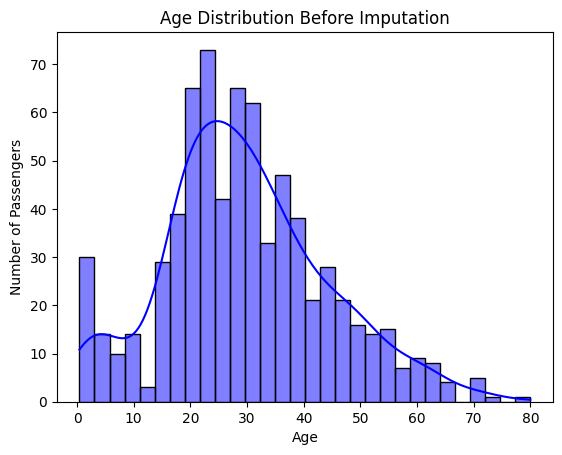

In [28]:
sns.histplot(
    df["Age"].dropna(),
    bins=30,
    kde=True,
    color="blue"
)

plt.title("Age Distribution Before Imputation")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

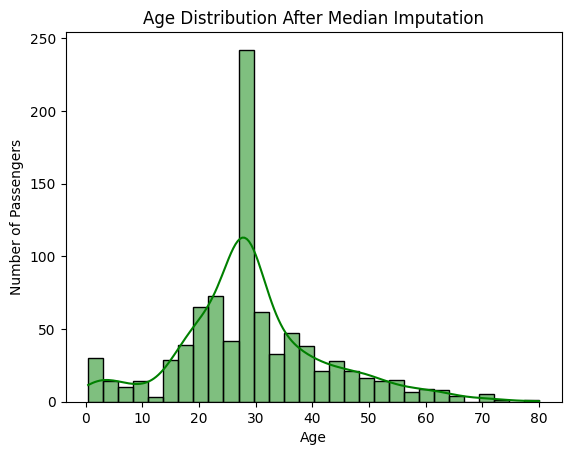

In [29]:
sns.histplot(
    df_clean["Age"],
    bins=30,
    kde=True,
    color="green"
)

plt.title("Age Distribution After Median Imputation")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

In [30]:
df_clean.head()
print(df_clean.isnull().sum())
print(df_clean.isnull().sum().sum())
print(df_clean.shape)

PassengerId    0
Survived       0
Pclass         0
Name           0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Sex_Encoded    0
Embarked_C     0
Embarked_Q     0
Embarked_S     0
dtype: int64
0
(891, 13)


In [31]:
df_clean.to_csv(
    "Titanic_Cleaned.csv",
    index=False
)
print("Titanic_Cleaned.csv created successfully")

Titanic_Cleaned.csv created successfully
